# CG-PED — Results Summary

**Do curriculum learning (C), LoRA (L), and knowledge distillation (D) compose?**

This notebook is the evaluation-metrics companion to the paper
(`../CG-PED_Research_Paper.docx`) and the codebase in this repository:
<https://github.com/AbelTez/Data_Compute_Efficient_GenAI_Research>

Every number and chart below is loaded from `results/factorial.json` and
`results/budget.json`, the files produced by `experiments/run_all.py` —
nothing is typed in by hand. Re-running the experiments and then this
notebook is the only step needed to refresh it.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fac = json.loads(Path("results/factorial.json").read_text())
bud = json.loads(Path("results/budget.json").read_text())

meta = fac["meta"]
print(f"Produced with PyTorch {meta['torch']} on 1 CPU thread — "
      f"seeds {meta['seeds']}, {meta['n_steps']} steps per run, "
      f"{meta['total_wall_clock_sec'] / 60:.0f} min total")

# Shared style, matching the paper's figures.
INK, NAIVE_C, FULL_C, MID_C, PRED_C = "#1f2937", "#2563eb", "#b91c1c", "#94a3b8", "#0f766e"
ORDER = ["---", "C--", "-L-", "--D", "CL-", "C-D", "-LD", "CLD"]
PRETTY = {"---": "naive", "C--": "C", "-L-": "L", "--D": "D",
          "CL-": "C+L", "C-D": "C+D", "-LD": "L+D", "CLD": "C+L+D\n(CG-PED)"}
BENCH = {"synthetic": "Synthetic SC-LM", "real": "Tiny Shakespeare (real text)"}

def clean(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

Produced with PyTorch 2.13.0+cpu on 1 CPU thread — seeds [7, 17, 27], 300 steps per run, 22 min total


## 1 · Evaluation metrics — every cell of the 2³ factorial

Cells are named by which factors are ON: `---` is the naive baseline
(random order, full fine-tune, plain cross-entropy), `CLD` is full CG-PED.
Each cell is trained with three seeds; the table reports the mean, the
seed-to-seed spread, perplexity, trainable-parameter count, and wall clock.
Nothing smaller than the seed spread is treated as a finding.

In [2]:
def metrics_table(bench):
    rows = []
    for c in ORDER:
        d = fac[bench]["cells"][c]
        v, p, w = d["val_loss"], d["val_ppl"], d["wall_clock_sec"]
        rows.append({
            "cell": c,
            "configuration": d["label"],
            "val loss": v["mean"],
            "± std": v["std"],
            "seed range": f"[{v['min']:.4f}, {v['max']:.4f}]",
            "perplexity": p["mean"],
            "trainable params": d["trainable_params"],
            "wall clock (s)": w["mean"],
        })
    return pd.DataFrame(rows).set_index("cell")

for bench in ("synthetic", "real"):
    df = metrics_table(bench)
    display(df.style
              .set_caption(f"{BENCH[bench]} — mean over 3 seeds")
              .format({"val loss": "{:.4f}", "± std": "{:.4f}",
                       "perplexity": "{:.2f}", "trainable params": "{:,}",
                       "wall clock (s)": "{:.1f}"})
              .highlight_min(subset=["val loss"], props="font-weight: bold;"))

,configuration,val loss,± std,seed range,perplexity,trainable params,wall clock (s)
cell,,,,,,,
---,"naive (random order, full fine-tune, no KD)",3.5287,0.0083,"[3.5230, 3.5382]",34.08,"81,920",12.1
C--,curriculum only,3.5156,0.0037,"[3.5118, 3.5191]",33.64,"81,920",12.5
-L-,LoRA only,3.5528,0.0015,"[3.5512, 3.5542]",34.91,"22,656",13.4
--D,distillation only,3.5169,0.0035,"[3.5129, 3.5190]",33.68,"81,920",26.0
CL-,curriculum + LoRA,3.5473,0.0067,"[3.5430, 3.5551]",34.72,"22,656",13.5
C-D,curriculum + distillation,3.5148,0.0026,"[3.5118, 3.5163]",33.61,"81,920",26.3
-LD,LoRA + distillation,3.5392,0.0091,"[3.5294, 3.5473]",34.44,"22,656",28.2
CLD,full CG-PED,3.5435,0.0086,"[3.5338, 3.5500]",34.59,"22,656",28.8


,configuration,val loss,± std,seed range,perplexity,trainable params,wall clock (s)
cell,,,,,,,
---,"naive (random order, full fine-tune, no KD)",2.1101,0.0054,"[2.1048, 2.1156]",8.25,"80,000",15.1
C--,curriculum only,2.1310,0.0141,"[2.1221, 2.1473]",8.42,"80,000",15.1
-L-,LoRA only,2.3840,0.0022,"[2.3824, 2.3865]",10.85,"20,736",16.6
--D,distillation only,2.0613,0.0163,"[2.0485, 2.0796]",7.86,"80,000",30.8
CL-,curriculum + LoRA,2.3877,0.0090,"[2.3774, 2.3942]",10.89,"20,736",17.0
C-D,curriculum + distillation,2.0809,0.0067,"[2.0766, 2.0886]",8.01,"80,000",30.6
-LD,LoRA + distillation,2.3587,0.0100,"[2.3494, 2.3693]",10.58,"20,736",32.3
CLD,full CG-PED,2.3642,0.0158,"[2.3472, 2.3784]",10.64,"20,736",32.7


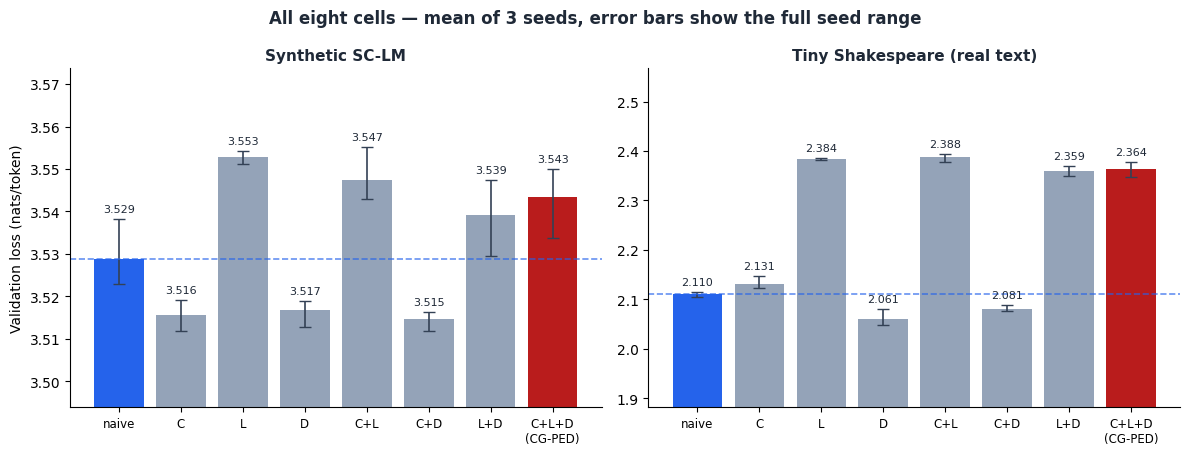

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, bench in zip(axes, ("synthetic", "real")):
    cells_ = fac[bench]["cells"]
    means = [cells_[c]["val_loss"]["mean"] for c in ORDER]
    lo = [m - cells_[c]["val_loss"]["min"] for c, m in zip(ORDER, means)]
    hi = [cells_[c]["val_loss"]["max"] - m for c, m in zip(ORDER, means)]
    colors = [NAIVE_C if c == "---" else FULL_C if c == "CLD" else MID_C for c in ORDER]
    xs = np.arange(len(ORDER))
    ax.bar(xs, means, yerr=[lo, hi], capsize=4, color=colors,
           error_kw=dict(ecolor="#334155", lw=1.2))
    span = max(means) - min(means)
    for x, m, h in zip(xs, means, hi):
        ax.text(x, m + h + span * 0.03, f"{m:.3f}", ha="center", va="bottom",
                fontsize=8, color=INK)
    ax.axhline(cells_["---"]["val_loss"]["mean"], color=NAIVE_C, ls="--", lw=1.2, alpha=.7)
    ax.set_xticks(xs, [PRETTY[c] for c in ORDER], fontsize=8.5)
    ax.set_ylim(min(means) - span * 0.55, max(means) + span * 0.55)
    ax.set_ylabel("Validation loss (nats/token)" if bench == "synthetic" else "")
    ax.set_title(BENCH[bench], fontsize=11, fontweight="bold", color=INK)
    clean(ax)
fig.suptitle("All eight cells — mean of 3 seeds, error bars show the full seed range",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

Blue is the naive baseline (dashed line = its mean), red is full CG-PED,
gray the six other combinations. On both benchmarks every cell containing
LoRA (`L`) sits visibly above the baseline, and full CG-PED loses to naive
by far more than the seed range on real text.

## 2 · Main effects, and the additivity check

A factor's **main effect** is the mean change in validation loss across the
four pairs of cells that differ only in that factor (negative = better).
The **additive prediction** for full CG-PED is the naive mean plus the three
main effects; the **composition gap** is what the full combination actually
achieved minus that prediction. A gap inside seed noise means the three
techniques do not interact — they compose additively.

In [4]:
rows = []
for bench in ("synthetic", "real"):
    a = fac[bench]["analysis"]
    rows.append({
        "benchmark": BENCH[bench],
        "effect C (curriculum)": a["main_effects"]["C"]["main_effect"],
        "effect L (LoRA)": a["main_effects"]["L"]["main_effect"],
        "effect D (distillation)": a["main_effects"]["D"]["main_effect"],
        "naive": a["naive_mean"],
        "additive prediction": a["additive_prediction"],
        "full CG-PED observed": a["full_cgped_mean"],
        "composition gap": a["composition_gap"],
        "seed noise (±)": a["pooled_within_cell_std"],
    })
effects = pd.DataFrame(rows).set_index("benchmark")
display(effects.style.set_caption("Main effects and additivity (validation loss, nats/token)")
        .format("{:+.4f}", subset=["effect C (curriculum)", "effect L (LoRA)",
                                   "effect D (distillation)", "composition gap"])
        .format("{:.4f}", subset=["naive", "additive prediction",
                                  "full CG-PED observed", "seed noise (±)"]))

,effect C (curriculum),effect L (LoRA),effect D (distillation),naive,additive prediction,full CG-PED observed,composition gap,seed noise (±)
benchmark,,,,,,,,
Synthetic SC-LM,-0.0041,+0.0267,-0.0075,3.5287,3.5438,3.5435,-0.0003,0.0055
Tiny Shakespeare (real text),+0.0124,+0.2778,-0.0369,2.1101,2.3634,2.3642,+0.0008,0.0099


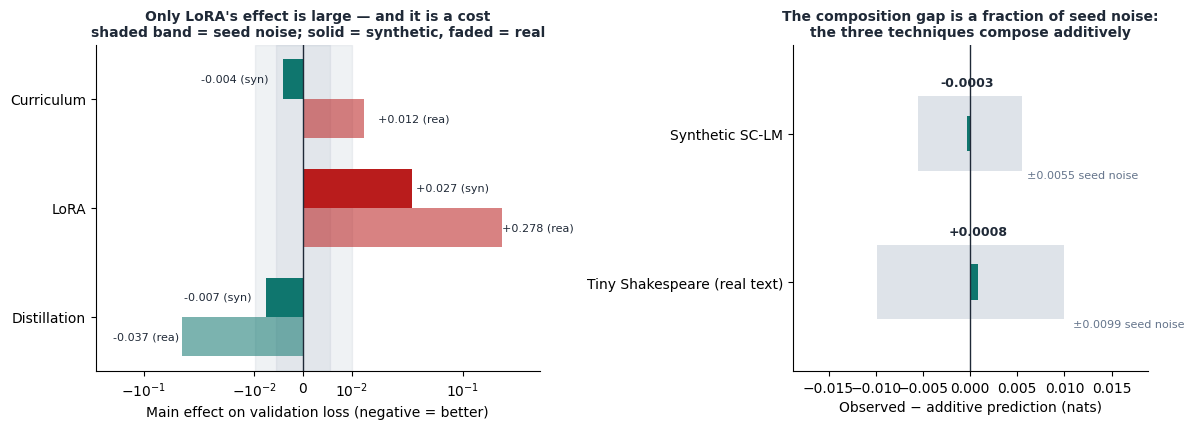

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4),
                               gridspec_kw={"width_ratios": [1.25, 1]})
ys = np.arange(3)
for i, bench in enumerate(("synthetic", "real")):
    a = fac[bench]["analysis"]
    vals = [a["main_effects"][f]["main_effect"] for f in "CLD"]
    sd = a["pooled_within_cell_std"]
    pos = ys + (i - 0.5) * 0.36
    colors = [PRED_C if v < 0 else FULL_C for v in vals]
    axL.barh(pos, vals, 0.36, color=colors, alpha=1.0 if i == 0 else 0.55)
    for p, v in zip(pos, vals):
        axL.text(v + (0.003 if v > 0 else -0.003), p, f"{v:+.3f} ({bench[:3]})",
                 va="center", ha="left" if v > 0 else "right", fontsize=8, color=INK)
    axL.axvspan(-sd, sd, color=MID_C, alpha=0.14, zorder=0)
axL.axvline(0, color=INK, lw=1)
axL.set_yticks(ys, ["Curriculum", "LoRA", "Distillation"])
axL.invert_yaxis()
axL.set_xscale("symlog", linthresh=0.02)
axL.set_xlim(-0.35, 0.75)
axL.set_xlabel("Main effect on validation loss (negative = better)")
axL.set_title("Only LoRA's effect is large — and it is a cost\n"
              "shaded band = seed noise; solid = synthetic, faded = real",
              fontsize=10, fontweight="bold", color=INK)
clean(axL)

for y, bench in enumerate(("synthetic", "real")):
    a = fac[bench]["analysis"]
    sd = a["pooled_within_cell_std"]
    axR.barh([y], [2 * sd], 0.5, left=-sd, color=MID_C, alpha=.3, zorder=0)
    axR.barh([y], [a["composition_gap"]], 0.24, color=PRED_C, zorder=2)
    axR.text(a["composition_gap"], y - 0.32, f"{a['composition_gap']:+.4f}",
             ha="center", fontsize=9, color=INK, fontweight="bold")
    axR.text(sd * 1.1, y + 0.3, f"±{sd:.4f} seed noise", fontsize=8, color="#64748b")
axR.axvline(0, color=INK, lw=1)
axR.set_yticks([0, 1], [BENCH[b] for b in ("synthetic", "real")])
axR.set_ylim(1.6, -0.6)
lim = max(fac[b]["analysis"]["pooled_within_cell_std"] for b in ("synthetic", "real")) * 1.9
axR.set_xlim(-lim, lim)
axR.set_xlabel("Observed − additive prediction (nats)")
axR.set_title("The composition gap is a fraction of seed noise:\n"
              "the three techniques compose additively",
              fontsize=10, fontweight="bold", color=INK)
clean(axR)
fig.tight_layout()
plt.show()

## 3 · Budget study — equal steps vs equal wall clock

Equal *steps* flatters CG-PED: its distillation arm runs a forward pass
through a teacher ~7× the student's size at every step, so one CG-PED step
costs about twice one naive step. The follow-up gives full CG-PED 900 steps
(3× budget) and asks (a) does it catch the naive baseline at all, and
(b) what does it reach inside the naive baseline's *wall-clock* budget?

In [6]:
rows = []
for bench in ("synthetic", "real"):
    o = bud[bench]
    rows.append({
        "benchmark": BENCH[bench],
        "naive @300 steps": o["target_naive_mean_val_loss"],
        "CG-PED @300 steps": o["equal_step_val_loss"]["mean"],
        "CG-PED best @900 steps": o["best_val_loss"]["mean"],
        "CG-PED @equal wall clock": o["equal_wall_clock_val_loss"]["mean"],
        "seeds catching up": f"{o['seeds_that_caught_up']}/3",
        "catch-up steps": str(o["catch_up_steps"]),
        "cost per step vs naive": f"{o['cost_ratio_per_step']}x",
    })
display(pd.DataFrame(rows).set_index("benchmark").style
        .set_caption("Validation loss under different budgets")
        .format("{:.4f}", subset=["naive @300 steps", "CG-PED @300 steps",
                                  "CG-PED best @900 steps", "CG-PED @equal wall clock"]))

,naive @300 steps,CG-PED @300 steps,CG-PED best @900 steps,CG-PED @equal wall clock,seeds catching up,catch-up steps,cost per step vs naive
benchmark,,,,,,,
Synthetic SC-LM,3.5287,3.5435,3.4855,3.6041,3/3,"[390, 360, 405]",2.27x
Tiny Shakespeare (real text),2.1101,2.3642,2.1116,2.5833,1/3,[795],2.14x


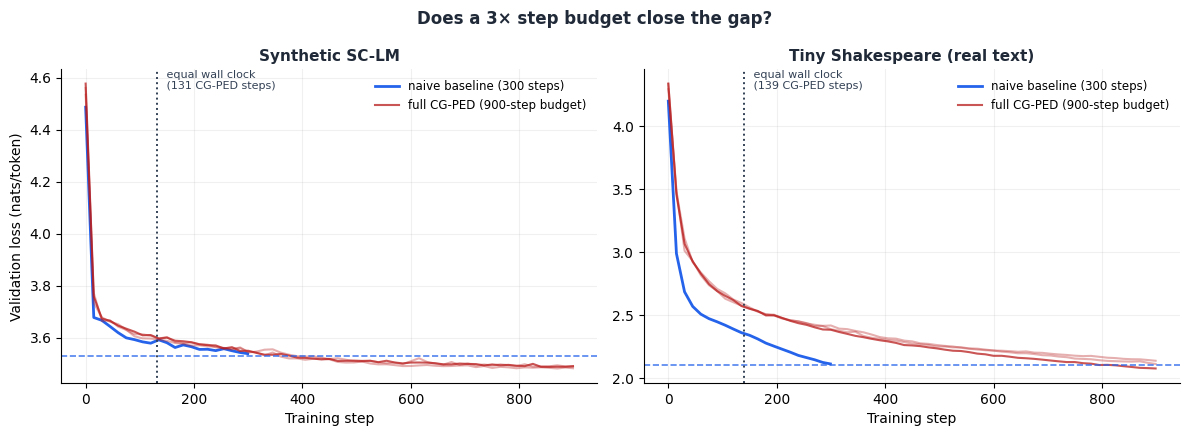

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, bench in zip(axes, ("synthetic", "real")):
    o = bud[bench]
    naive_hist = fac[bench]["cells"]["---"]["runs"][0]["history"]
    ax.plot([h["step"] for h in naive_hist], [h["val_loss"] for h in naive_hist],
            color=NAIVE_C, lw=2, label=f"naive baseline ({o['naive_steps']} steps)")
    for i, r in enumerate(o["runs"]):
        ax.plot([h["step"] for h in r["history"]], [h["val_loss"] for h in r["history"]],
                color=FULL_C, lw=1.5, alpha=.75 if i == 0 else .35,
                label="full CG-PED (900-step budget)" if i == 0 else None)
    ax.axhline(o["target_naive_mean_val_loss"], color=NAIVE_C, ls="--", lw=1.2, alpha=.8)
    eq = int(np.mean([r["steps_within_naive_wall_clock"] for r in o["runs"]]))
    ax.axvline(eq, color="#334155", ls=":", lw=1.4)
    ax.text(eq + 12, ax.get_ylim()[1], f" equal wall clock\n ({eq} CG-PED steps)",
            fontsize=8, color="#334155", va="top")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Validation loss (nats/token)" if bench == "synthetic" else "")
    ax.set_title(BENCH[bench], fontsize=11, fontweight="bold", color=INK)
    ax.legend(frameon=False, fontsize=8.5)
    ax.grid(alpha=.18)
    clean(ax)
fig.suptitle("Does a 3× step budget close the gap?", fontsize=12,
             fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

## 4 · Qualitative check — generated text

Both models produce recognisably Shakespeare-shaped character text after a
few hundred steps; at these loss levels a sample cannot rank two models,
and it is shown for honesty rather than as evidence.

In [8]:
q = bud["real"]["qualitative_samples"]
print(f"prompt: {q['prompt']!r}   (temperature {q['temperature']})\n")
print("--- naive baseline ---")
print(q["naive"])
print()
print("--- full CG-PED ---")
print(q["full_cgped"])

prompt: 'ROMEO:\n'   (temperature 0.8)

--- naive baseline ---
ROMEO:
Thakblly go fol mave mor bre wing ands of my how
This tha

--- full CG-PED ---
ROMEO:
On the pidgey pore theing not the upfor ther shey.

LUSTE


In [9]:
from IPython.display import Markdown

sa, ra = fac["synthetic"]["analysis"], fac["real"]["analysis"]
sb, rb = bud["synthetic"], bud["real"]

def best(bench):
    c, v = min(((c, d["val_loss"]["mean"]) for c, d in fac[bench]["cells"].items()),
               key=lambda kv: kv[1])
    return c, fac[bench]["cells"][c]["label"], v

sc, sl, sv = best("synthetic")
rc, rl, rv = best("real")

Markdown(f"""
## Final summary

1. **The three techniques compose additively.** The full combination lands
   within {abs(sa['composition_gap']):.4f} (synthetic) and
   {abs(ra['composition_gap']):.4f} (real) nats of what its three separate
   effects predict — a fraction of the ±{sa['pooled_within_cell_std']:.4f} /
   ±{ra['pooled_within_cell_std']:.4f} seed noise. No synergy, no interference.

2. **Because nothing compounds, the composition is worth the plain sum of its
   parts — and that sum is negative.** LoRA at from-scratch scale costs
   {sa['main_effects']['L']['main_effect']:+.3f} (synthetic) and
   {ra['main_effects']['L']['main_effect']:+.3f} (real) nats, by far the
   largest effect. Distillation helps ({sa['main_effects']['D']['main_effect']:+.3f} /
   {ra['main_effects']['D']['main_effect']:+.3f}), an order of magnitude less.
   The curriculum never clears its own noise floor and changes sign
   ({sa['main_effects']['C']['main_effect']:+.3f} / {ra['main_effects']['C']['main_effect']:+.3f}).

3. **Full CG-PED therefore trails the naive baseline** by
   {sa['observed_vs_naive']:+.4f} (synthetic) and {ra['observed_vs_naive']:+.4f}
   (real) nats at equal steps — while saving {sa['param_reduction_pct']}–{ra['param_reduction_pct']}%
   of trainable parameters at roughly twice the wall-clock cost per step
   ({sb['cost_ratio_per_step']}× synthetic, {rb['cost_ratio_per_step']}× real). Under an equal *wall-clock* budget the gap
   widens to {sb['equal_wall_clock_val_loss']['mean'] - sb['target_naive_mean_val_loss']:+.3f}
   and {rb['equal_wall_clock_val_loss']['mean'] - rb['target_naive_mean_val_loss']:+.3f} nats.

4. **The configuration this study recommends is not its own method:**
   `{sc}` ({sl}) reaches {sv:.4f} on synthetic and `{rc}` ({rl}) reaches
   {rv:.4f} on real text — both beat the naive baseline by more than the
   seed spread.

**Scope:** ~80K-parameter from-scratch models, hundreds of steps, CPU only,
3 seeds per cell. These results establish the mechanism at this scale; they
do not predict deployment-scale behaviour, and LoRA is measured outside the
pretrained-adaptation setting it was designed for (paper, Section 7).
""")


## Final summary

1. **The three techniques compose additively.** The full combination lands
   within 0.0003 (synthetic) and
   0.0008 (real) nats of what its three separate
   effects predict — a fraction of the ±0.0055 /
   ±0.0099 seed noise. No synergy, no interference.

2. **Because nothing compounds, the composition is worth the plain sum of its
   parts — and that sum is negative.** LoRA at from-scratch scale costs
   +0.027 (synthetic) and
   +0.278 (real) nats, by far the
   largest effect. Distillation helps (-0.007 /
   -0.037), an order of magnitude less.
   The curriculum never clears its own noise floor and changes sign
   (-0.004 / +0.012).

3. **Full CG-PED therefore trails the naive baseline** by
   +0.0148 (synthetic) and +0.2541
   (real) nats at equal steps — while saving 72.3–74.1%
   of trainable parameters at roughly twice the wall-clock cost per step
   (2.27× synthetic, 2.14× real). Under an equal *wall-clock* budget the gap
   widens to +0.075
   and +0.473 nats.

4. **The configuration this study recommends is not its own method:**
   `C-D` (curriculum + distillation) reaches 3.5148 on synthetic and `--D` (distillation only) reaches
   2.0613 on real text — both beat the naive baseline by more than the
   seed spread.

**Scope:** ~80K-parameter from-scratch models, hundreds of steps, CPU only,
3 seeds per cell. These results establish the mechanism at this scale; they
do not predict deployment-scale behaviour, and LoRA is measured outside the
pretrained-adaptation setting it was designed for (paper, Section 7).
